# Import modules

In [1]:
import numpy as np
import pandas as pd
from scipy import special
from pipedream_solver.hydraulics import SuperLink
from pipedream_solver.nquality import QualityBuilder
from pipedream_solver.simulation import Simulation
from pipedream_solver.diagnostics import PerformanceTracker
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Read input data

In [2]:
input_path = '../data/hillslope_wq'
superjunctions = pd.read_csv(f'{input_path}/Simple_superjunctions.csv')
superlinks = pd.read_csv(f'{input_path}/Simple_superlinks.csv')
superlink_wq_params = pd.read_csv(f'{input_path}/Simple_superlink_wq_params.csv')
superjunction_wq_params = pd.read_csv(f'{input_path}/Simple_superjunction_wq_params.csv')

# input boundary 
H_bc = pd.read_csv(f'{input_path}/Simple_boundary_stage.csv', index_col=0)

# Instantiate model

In [3]:
# Simulation parameters
dt = 1
T_max = 1200.
internal_links = 500
C_start = 0
C_end = 1200
C_input = 10
spinup_steps = 1

hydraulic_model = SuperLink(superlinks, superjunctions, internal_links=internal_links)
transport_model = QualityBuilder(hydraulic_model, superjunction_params=superjunction_wq_params,
                                 superlink_params=superlink_wq_params)

# Spin up model
hydraulic_model.spinup(n_steps=spinup_steps)

# Initialize volume for mass balance tracking
hydraulic_model.volume_tracker.set_init_volume()

# Add run-time performance tracker
performance_tracker = PerformanceTracker(hydraulic_model)
hydraulic_model.bind_callback(performance_tracker, 'performance_tracker')
hydraulic_model.performance_tracker = performance_tracker

# Set parameters for Newton iterations
hydraulic_model.convergence_tracker.max_learning_rate = 1.
hydraulic_model.convergence_tracker.beta = 2.
hydraulic_model.convergence_tracker.xtol = 1e-5
hydraulic_model.convergence_tracker.min_learning_rate = 0.05

## Run simulation

In [4]:
# Create dictionaries to store diagnostic information
iterations_elapsed = {}
convergence_queues = {}
learning_queues = {}
error_queues = {}
volume_in_system = {}
volume_net_added = {}
step_time_taken = {}

In [5]:
c_ik = []

with Simulation(hydraulic_model, dt=dt, H_bc=H_bc, t_end=T_max) as simulation:
    while simulation.t <= T_max:
        # setting the contaminant input duration
        if (hydraulic_model.t > C_start) and (hydraulic_model.t <= C_end):
            # Apply contaminant to uphill superjunction
            Q_in = 0.5 * np.asarray([1.,0.])
            c_0j = C_input * np.asarray([1., 0.])
        else:
            # Otherwise, no contaminant input
            Q_in = 0.5 * np.asarray([1.,0.])
            c_0j = np.zeros(2)
        # Advance hydraulic model
        hydraulic_model.step(dt=dt, Q_in=Q_in)
        # Advance water quality model
        transport_model.step(dt=dt, c_0j=c_0j)
        # Record states
        simulation.record_state()
        simulation.print_progress()
        # Record nodal contaminant concentrations
        c_ik.append(transport_model.c_ik.copy())
        # Record diagnostic metrics
        iterations_elapsed[simulation.t] = hydraulic_model.iter_elapsed
        convergence_queues[simulation.t] = hydraulic_model.convergence_tracker.convergence_queue
        error_queues[simulation.t] = hydraulic_model.convergence_tracker.error_queue
        learning_queues[simulation.t] = hydraulic_model.convergence_tracker.learning_queue
        volume_in_system[simulation.t] = hydraulic_model.volume_tracker.total_volume
        volume_net_added[simulation.t] = hydraulic_model.volume_tracker.cumulative_volume_flux
        step_time_taken[simulation.t] = hydraulic_model.performance_tracker.step_time_elapsed


[==================================================] 100.0% [1787196691.38 s]

In [6]:
# NOTE: Timer is incorrect because simulation.step is never called, and _clock_start_time is never updated

## Analytical solution

In [7]:
# Analytical solution: time series
K = transport_model._K_ik[1]                                  # Reaction
D = transport_model._D_ik[1]                                  # Diffusion coefficient
Vx = np.mean(hydraulic_model.Q_ik[1:1000]/hydraulic_model.A_ik[1:1000])    # velocity
x = np.linspace(1,1000,1000)
Gamma = np.sqrt(1+(4*K*D/pow(Vx,2)))
tau = C_end - 0.0000001
C0 = C_input

#Analytical solution: spatial
t = T_max
tau = C_end - 0.0000001

X_location = np.zeros(1000)
X_location[0] = hydraulic_model._dx_ik[1]/2
C_Analytical_space = np.zeros(1000)

X_location = x
for i in range(0,1000): 
    C_An_Temp = special.erfc((X_location[i]-Vx*t*Gamma)/(2*np.sqrt(D*t)))
    C_An_Temp += -special.erfc((X_location[i]-Vx*(t-tau)*Gamma)/(2*np.sqrt(D*(t-tau))))
    C_Analytical_space[i] = 0.5*C0*np.exp(Vx*X_location[i]*(1-Gamma)/(2*D))*C_An_Temp
    C_An_Temp = special.erfc((X_location[i]+Vx*t*Gamma)/(2*np.sqrt(D*t)))
    C_An_Temp += -special.erfc((X_location[i]+Vx*(t-tau)*Gamma)/(2*np.sqrt(D*(t-tau))))
    C_Analytical_space[i] += np.exp(Vx*X_location[i]*(1+Gamma)/(2*D)) * C_An_Temp

## Plot comparison against analytical solution

<Figure size 640x480 with 0 Axes>

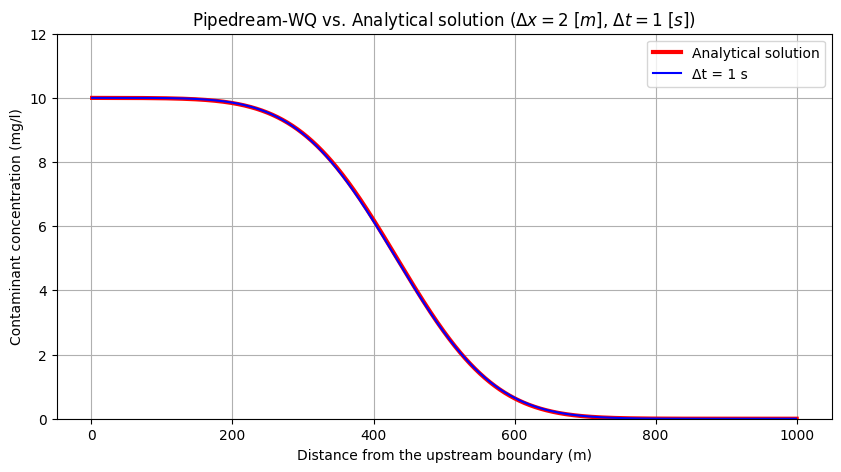

In [8]:
# Print the results: for dt
plt.figure()
plt.figure(figsize= (10,5))
plt.plot(x,C_Analytical_space, color = 'r', linewidth = 3, label = 'Analytical solution')
c_ik = np.array(c_ik)
s2 = np.linspace(0.5*1000/internal_links, 0.5*1000/internal_links + 1000*(internal_links-1)/internal_links, internal_links)
plt.plot(s2, c_ik[int(T_max/dt), 0:internal_links+1], '-', color = 'b', linewidth = 1.5, label = f'Δt = {dt} s')
plt.title(f'Pipedream-WQ vs. Analytical solution $(\Delta x = {1000//internal_links}~[m]$, $\Delta t = {dt}~[s])$')
plt.ylim(0,12)
plt.xlabel('Distance from the upstream boundary (m)')
plt.ylabel('Contaminant concentration (mg/l)')
plt.legend()
plt.grid()

# Mass balance analysis

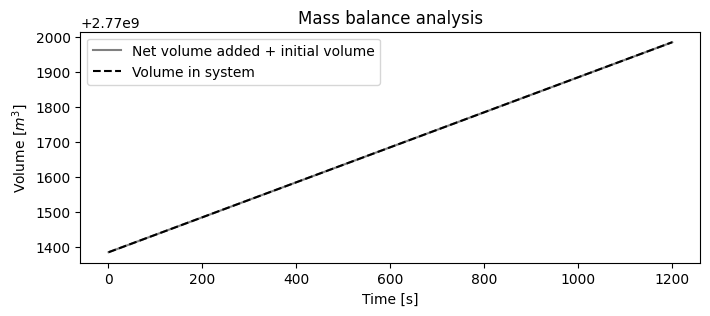

In [9]:
fig, ax = plt.subplots(figsize=(8, 3))
(pd.Series(volume_net_added) + hydraulic_model.volume_tracker.init_volume).plot(ax=ax, label='Net volume added + initial volume', c='0.5')
pd.Series(volume_in_system).plot(ax=ax, label='Volume in system', c='k', linestyle='--')
plt.xlabel('Time [s]')
plt.ylabel('Volume [$m^3$]')
plt.title('Mass balance analysis')
_ = plt.legend()

# Convergence analysis

### Step convergence criterion $||x_{new} - x_{old}||_\infty$

In [10]:
#sns.set_palette('viridis', len(convergence_queues))
#fig, ax = plt.subplots(figsize=(8, 4))
#for key in convergence_queues:
#    ax.plot(np.log10(np.vstack(convergence_queues[key])).max(axis=1))
#_ = plt.title('$\log_{10} ||x_{new} - x_{old}||_\infty$')
#_ = plt.xlabel('Iteration')
#_ = plt.ylabel('$\log_{10} ||x_{new} - x_{old}||_\infty$')

### Error convergence criterion $||f(x)||_\infty$

In [11]:
#sns.set_palette('viridis', len(convergence_queues))
#fig, ax = plt.subplots(figsize=(8, 4))
#for key in error_queues:
#    ax.plot(np.log10(np.array(error_queues[key])))
#_ = plt.title('$\log_{10} ||f(x)||_\infty$')
#_ = plt.xlabel('Iteration')
#_ = plt.ylabel('$\log_{10} ||f(x)||_\infty$')


### Newton step size

In [12]:
#sns.set_palette('viridis', len(convergence_queues))
#fig, ax = plt.subplots(figsize=(8, 4))
#for key in learning_queues:
#    ax.plot(np.array(learning_queues[key]))
#_ = plt.title('Newton step size ($\\alpha$)')
#_ = plt.xlabel('Iteration')
#_ = plt.ylabel('$\\alpha$')


### Number of iterations elapsed

Text(0, 0.5, 'Iterations')

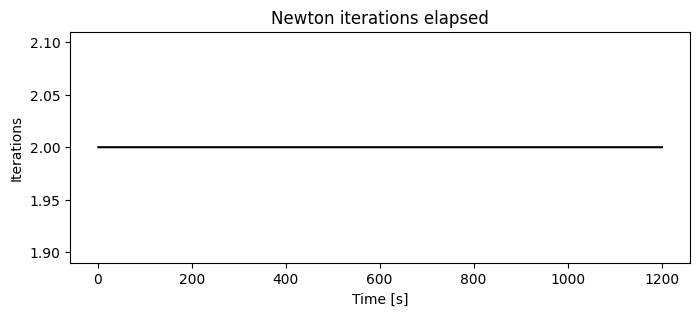

In [13]:
fig, ax = plt.subplots(figsize=(8, 3))
pd.Series(iterations_elapsed).plot(ax=ax, c='k')
plt.title('Newton iterations elapsed')
plt.xlabel('Time [s]')
plt.ylabel('Iterations')

### Simulation time elapsed

Text(0, 0.5, 'Clock time elapsed [s]')

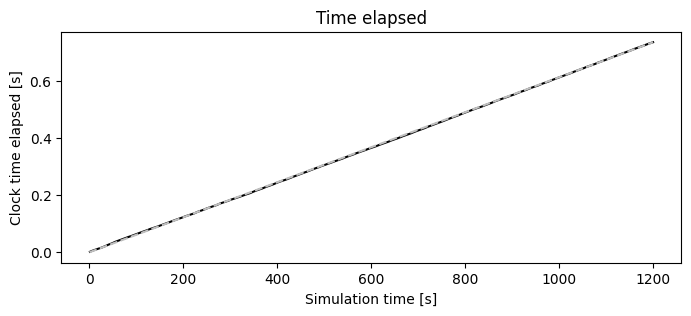

In [14]:
fig, ax = plt.subplots(figsize=(8, 3))
pd.Series(step_time_taken).cumsum().plot(ax=ax, c='k')
plt.plot([0, simulation.t], [0, pd.Series(step_time_taken).cumsum().iloc[-1]], c='0.75', linestyle='--')
plt.title('Time elapsed')
plt.xlabel('Simulation time [s]')
plt.ylabel('Clock time elapsed [s]')